# 01 — Exploratory Data Analysis

The goal of this notebook is to understand what's in our match-history data before we start modeling.

**Why EDA matters:** Every choice we'll make later, such as which features to use, which years to keep, how to handle missing data, what loss function to optimize, all depend on knowing what the data actually looks like. Skipping EDA is the most common way to ship a quietly broken model.

This covers:

1. Date coverage and matches-per-year over time
2. Missing/null values
3. Tournament breakdown (friendly vs. competitive vs. WC)
4. Goals-per-match distribution (this directly informs our Poisson choice)
5. Home advantage size
6. Scoring rate over time
7. Country-name consistency

All data is filtered to **before 2026-06-11** (the WC 2026 cutoff). We do not look at WC 2026 games in this notebook.

In [7]:
import sys
from pathlib import Path

# Make `src` importable when running the notebook from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_results, load_shootouts, load_former_names

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df, report = load_results(apply_cutoff=True)
print(report.summary())
df.head()

rows: 49,477
date range: 1872-11-30 → 2026-06-27
rows on/after 2026-06-11 (WC 2026 + future): 72


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 1. Date coverage and density

Football has changed enormously since 1872. There were ~5 international matches in 1872 and 1,800+ in recent years.

**Why this matters for modeling:** when we fit our model, every match counts as one "training example." If we just throw all 49k matches in equally, the model's view of "how a team plays" will mostly be shaped by recent years (which makes sense — that's where most of the matches live). But team-strength estimates (like Elo ratings, which we'll build in the next task) update *iteratively* through every match in chronological order — so old matches still propagate forward and can pull a team's current rating in weird directions if the data is sparse or unrepresentative.

The chart below will tell us roughly where the data becomes dense and "modern" enough that we can probably trust it as-is.

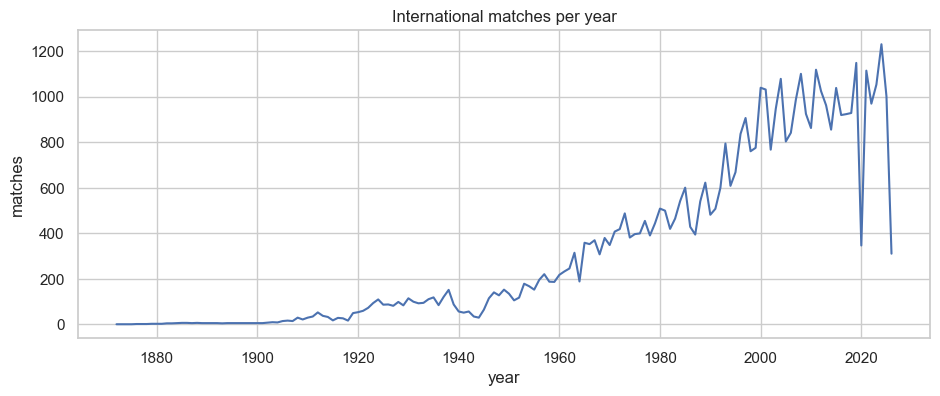

earliest year: 1872
latest year:   2026
median matches/year (pre-1950):  24
median matches/year (post-2000): 970


In [8]:
df["year"] = pd.to_datetime(df["date"]).dt.year
matches_per_year = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(11, 4))
matches_per_year.plot(ax=ax)
ax.set_title("International matches per year")
ax.set_ylabel("matches")
ax.set_xlabel("year")
plt.show()

print(f"earliest year: {matches_per_year.index.min()}")
print(f"latest year:   {matches_per_year.index.max()}")
print(f"median matches/year (pre-1950):  {int(matches_per_year[matches_per_year.index < 1950].median())}")
print(f"median matches/year (post-2000): {int(matches_per_year[matches_per_year.index >= 2000].median())}")

## 2. Missing values

After applying the WC 2026 cutoff, are there any rows with missing scores? Anything else broken?

In [9]:
print("nulls per column:")
print(df.isna().sum())
print()
print(f"score dtype: home={df['home_score'].dtype}, away={df['away_score'].dtype}")
print(f"min home_score: {df['home_score'].min()}, max: {df['home_score'].max()}")
print(f"min away_score: {df['away_score'].min()}, max: {df['away_score'].max()}")

nulls per column:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
year          0
dtype: int64

score dtype: home=float64, away=float64
min home_score: 0.0, max: 31.0
min away_score: 0.0, max: 21.0


## 3. Tournament breakdown

Not all matches are created equal. The same two teams playing a friendly in March vs. a World Cup quarterfinal in July are different games in three measurable ways:

- **Squad selection** — friendlies often rotate the squad and rest stars; competitive matches feature the best XI.
- **Effort level** — players genuinely try harder in matches that matter for trophies or qualification.
- **Defensive caution** — knockout matches tend to be lower-scoring because teams play more carefully.

**Why this matters for the model:** if the data shows (for example) that friendlies have systematically higher scoring than World Cup games, then treating them identically when fitting team strengths would mean a team's "true" attacking strength gets inflated by their friendly results. We have two options later:

1. Add a feature flag (`is_friendly`, `is_world_cup`, etc.) so the model can adjust its prediction up or down based on the tournament type.
2. Down-weight friendlies during training (give them less influence than competitive matches).

We'll see what the data says and pick. First, let's just see how many of each type we have.

In [10]:
tournament_counts = df["tournament"].value_counts()
print(f"distinct tournament names: {len(tournament_counts)}")
print()
print("top 15 by match count:")
print(tournament_counts.head(15))

distinct tournament names: 200

top 15 by match count:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64


In [ ]:
# Coarse buckets for modeling later.
# Order matters: check "qualif" BEFORE "world cup" because
# "FIFA World Cup qualification" contains both substrings.
def classify_tournament(name: str) -> str:
    name = name.lower()
    if "friendly" in name:
        return "friendly"
    if "qualif" in name:
        return "qualifier"
    if "world cup" in name or "fifa" in name:
        return "world_cup"
    if any(k in name for k in ["euro", "copa", "africa", "asian", "concacaf", "uefa", "afcon", "gold cup", "nations league"]):
        return "continental"
    return "other"

df["tournament_class"] = df["tournament"].apply(classify_tournament)
df["tournament_class"].value_counts()

## 4. Goals per match — the Poisson question

The Poisson distribution describes the count of events that happen at a roughly constant, independent rate. Classic examples: number of emails arriving in an hour, number of typos per page, number of customers walking into a shop. **Goals in a soccer match** are a famous example too — most matches have a small whole number (0, 1, 2, 3 are common; 7+ is rare).

A Poisson distribution has one parameter, written `lambda` (λ). It's the *expected count* — the average. Once you know λ, the entire shape of the distribution is fixed: P(0 goals), P(1 goal), P(2 goals), and so on, are all determined.

A peculiar mathematical property of the Poisson distribution: **the mean and the variance are both equal to λ.** That means if matches really do follow a Poisson distribution, then the average goals per game and the variance (spread) of goals per game should be the same number.

**Why this matters for our model:** our entire approach assumes that goals are Poisson-distributed. If the real data has variance much larger than the mean (a phenomenon called *overdispersion* — i.e., the data is "more spread out" than Poisson predicts), then a pure Poisson model will systematically underestimate the chance of extreme scores (5-0, 6-1, etc.) and overestimate boring scores. That would matter for our exact-score predictions in particular.

The cell below computes:
- empirical mean of goals scored per team per match
- empirical variance of the same
- their ratio (which should be ~1.0 if Poisson fits well)
- a visual overlay of the empirical distribution vs. a theoretical Poisson with the same mean

goals per team-match (2000+): mean = 1.378, variance = 2.446
variance / mean ratio: 1.776  (Poisson would be ~1.0)


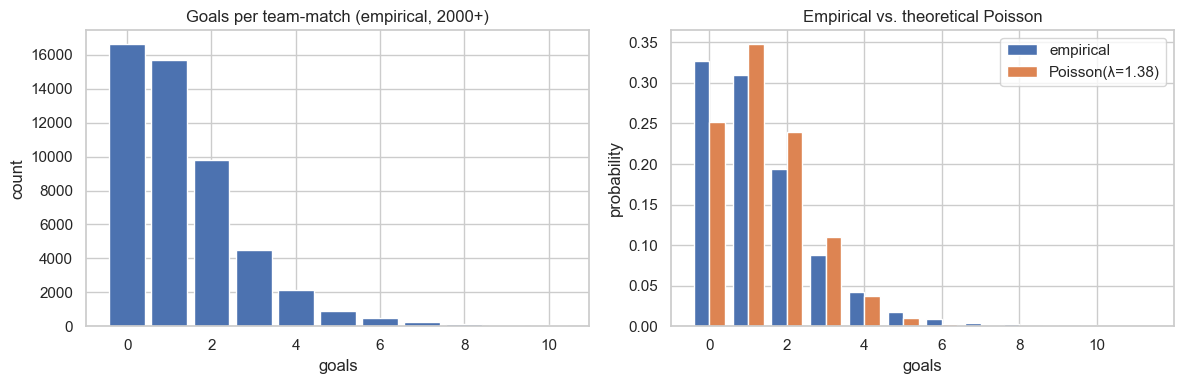

In [12]:
recent = df[pd.to_datetime(df["date"]) >= "2000-01-01"].copy()
goals = pd.concat([recent["home_score"], recent["away_score"]])

mean_g = goals.mean()
var_g = goals.var()
print(f"goals per team-match (2000+): mean = {mean_g:.3f}, variance = {var_g:.3f}")
print(f"variance / mean ratio: {var_g / mean_g:.3f}  (Poisson would be ~1.0)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(goals, bins=range(0, 12), align="left", rwidth=0.85)
axes[0].set_title("Goals per team-match (empirical, 2000+)")
axes[0].set_xlabel("goals")
axes[0].set_ylabel("count")

# Overlay theoretical Poisson with the same mean
from scipy.stats import poisson
xs = np.arange(0, 12)
axes[1].bar(xs - 0.2, np.bincount(goals.dropna().astype(int), minlength=12)[:12] / len(goals.dropna()),
            width=0.4, label="empirical")
axes[1].bar(xs + 0.2, poisson.pmf(xs, mean_g), width=0.4, label=f"Poisson(λ={mean_g:.2f})")
axes[1].set_title("Empirical vs. theoretical Poisson")
axes[1].set_xlabel("goals")
axes[1].set_ylabel("probability")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Home advantage

Playing at home boosts a team's **expected goal count** by roughly 0.4 to 0.6 goals per match (in international football). The number is in literal *units of goals* — meaning that if the same two teams played twice, once at Team A's home and once on a neutral pitch, Team A would be expected to score about half a goal more in the home version, on average.

This is different from "home win probability" (which runs around 50–55%); the goal-based number is what we use because it plugs directly into our Poisson model: we add a small additive home boost to `lambda_home` and the math works out.

Let's measure both numbers in our data. We compare matches with `neutral=False` vs. `neutral=True`. If home advantage is real, the non-neutral games should show:
- a meaningfully positive average goal margin for the home team, and
- a home-win rate well above the ~33% you'd see if W/D/L were equally likely.

In [13]:
recent["margin"] = recent["home_score"] - recent["away_score"]

home_games = recent[~recent["neutral"]]
neutral_games = recent[recent["neutral"]]

print(f"home games (2000+): {len(home_games):,}")
print(f"  avg home_score: {home_games['home_score'].mean():.3f}")
print(f"  avg away_score: {home_games['away_score'].mean():.3f}")
print(f"  avg margin:     {home_games['margin'].mean():+.3f}")
print(f"  home win rate:  {(home_games['margin'] > 0).mean():.1%}")
print()
print(f"neutral games (2000+): {len(neutral_games):,}")
print(f"  avg home_score: {neutral_games['home_score'].mean():.3f}")
print(f"  avg away_score: {neutral_games['away_score'].mean():.3f}")
print(f"  avg margin:     {neutral_games['margin'].mean():+.3f}")
print(f"  home win rate:  {(neutral_games['margin'] > 0).mean():.1%}")

home games (2000+): 18,112
  avg home_score: 1.695
  avg away_score: 1.020
  avg margin:     +0.674
  home win rate:  50.8%

neutral games (2000+): 7,231
  avg home_score: 1.516
  avg away_score: 1.341
  avg margin:     +0.174
  home win rate:  41.5%


## 6. Scoring rate over time

Has the average goals-per-match changed across eras? This matters because our model assumes there's a "current" scoring rate that we're trying to estimate. If the rate has drifted significantly (e.g., teams in the 1920s scored 4+ per game on average and modern teams score 2.5), then including 1920s data in our training pulls our estimate of "normal scoring rate" toward a number that no longer reflects modern football.

If we see a clear shift, our options are:

1. **Cut off old data entirely** — only train on matches from 1970+ (or some other year).
2. **Weight by recency** — every match counts, but recent matches count more (e.g., a 2024 match contributes 1.0 to the loss, a 2000 match contributes 0.5, a 1950 match contributes 0.05). This is called *time-weighted training*.

Both are valid. We'll likely use option 1 first because it's simpler.

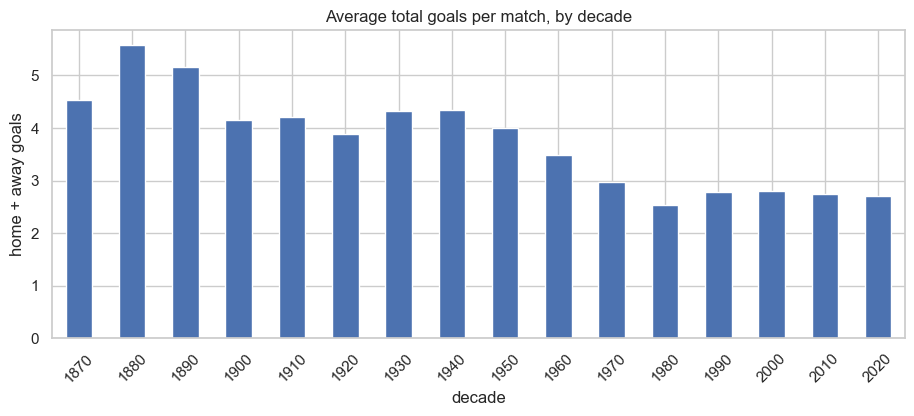

decade
1930    4.32
1940    4.34
1950    4.00
1960    3.48
1970    2.97
1980    2.53
1990    2.78
2000    2.80
2010    2.74
2020    2.71
dtype: float64

In [14]:
df["decade"] = (df["year"] // 10) * 10
goals_by_decade = df.groupby("decade").apply(
    lambda g: (g["home_score"].mean() + g["away_score"].mean()),
    include_groups=False,
)

fig, ax = plt.subplots(figsize=(11, 4))
goals_by_decade.plot(kind="bar", ax=ax)
ax.set_title("Average total goals per match, by decade")
ax.set_ylabel("home + away goals")
ax.set_xlabel("decade")
plt.xticks(rotation=45)
plt.show()

goals_by_decade.tail(10).round(2)

## 7. Country-name consistency

`former_names.csv` provides historical renames. We need every team name in `results.csv` to either (a) be a current country, or (b) have a mapping to a current country in `former_names.csv`.

**Why this matters:** in the next task we'll compute **Elo ratings** for every team — a single number per team that updates after every match they play (rating goes up when they win, down when they lose, more so when they beat a strong team or lose to a weak one). The whole system assumes "a team" is a stable identity over time.

If "West Germany" (lots of matches 1949–1990) and "Germany" (matches since 1990) appear as two separate team names with no mapping between them, our Elo system will treat them as two completely different teams. "Germany" would start in 1990 with no rating history, ignoring 40 years of West Germany's results. That's wrong: Germany inherited West Germany's squad, federation, infrastructure, and football culture — and footballing strength rarely changes overnight.

We need to fix this *before* computing Elo. The cell below lists every team name in our data that needs to be mapped to a current name.

In [ ]:
# Two views:
# (1) teams whose name is listed as a "former" in former_names.csv
#     — these have a clean rename mapping we can apply directly.
# (2) teams that played their last match before 2000
#     — these are likely defunct national teams (countries that split,
#       ceased to exist, or were renamed without a clean successor).
#       The Elo system can handle these naturally: they accumulate a
#       rating until they stop playing, then never appear again.

former = load_former_names()
teams_in_results = set(df["home_team"]).union(df["away_team"])
former_names_listed = set(former["former"])

with_clean_rename = sorted(t for t in teams_in_results if t in former_names_listed)
print("(1) teams in results that match a 'former' entry (clean rename exists):")
for t in with_clean_rename:
    print(f"  - {t}")
if not with_clean_rename:
    print("  (none — the dataset maintainer appears to already apply these renames)")

print()
print("(2) defunct teams (last match before 2000):")
last_match = pd.concat([
    df[["home_team", "date"]].rename(columns={"home_team": "team"}),
    df[["away_team", "date"]].rename(columns={"away_team": "team"}),
]).groupby("team")["date"].max()
defunct = last_match[last_match < pd.Timestamp("2000-01-01").date()].sort_values()
print(f"  found {len(defunct)} defunct teams. Notable ones:")
notable = ["German DR", "Czechoslovakia", "Yugoslavia", "Soviet Union", "Serbia and Montenegro"]
for name in notable:
    if name in defunct.index:
        print(f"  - {name}: last played {defunct[name]}")
    elif name in last_match.index:
        print(f"  - {name}: still active (last played {last_match[name]})")

## Summary

Things to decide based on what we just saw:

1. **Start year for training data** *(from sections 1 and 6).* Pre-1950 has very few matches per year and possibly a different scoring rate. We may train on 1950+ or 1970+ only. The bar chart in section 6 will tell us where the rate stabilizes.

2. **Whether plain Poisson is good enough** *(from section 4).* If the variance/mean ratio in section 4 is close to 1.0, plain Poisson is fine. If it's noticeably above 1.0 (say >1.2), the data is *overdispersed* — meaning extreme scores happen more often than Poisson predicts. Two ways to handle this:
   - **Dixon-Coles correction** — a small tweak that specifically fixes Poisson's tendency to mis-predict low-scoring draws (0-0, 1-1, 1-0). This is the most popular fix in football modeling and the one we planned for.
   - **Negative binomial regression** — a different distribution that allows mean ≠ variance. Bigger change, more flexibility.

3. **Home advantage size** *(from section 5).* The empirical goal margin and home win rate set our expectation for what the model should "rediscover" when we fit it.

4. **Country-name mapping** *(from section 7).* Section 7 lists the names we must map before computing Elo. We'll build a `canonicalize_team()` function in `src/features/` that applies these renames.

5. **Tournament weighting** *(from section 3).* If certain tournament types behave very differently (e.g., friendlies have much higher scoring), we'll add a `tournament_class` feature or down-weight friendlies.